<h1 align="center"><b>Homework Assignment 3 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 5</b></h3>
<h3 align="center"><b>Due at the end of Module 7</b></h3><br>

# Q1 — Solving Einstein’s Riddle as a CSP

## 35 points total

**Einstein’s Riddle:**

There are **5 houses in a row**, each with a different color. Each house has an owner of a different nationality, a pet, a drink, and a cigar brand. The following clues apply:

1. The Brit lives in the red house.  
2. The Swede keeps dogs as pets.  
3. The Dane drinks tea.  
4. The green house is immediately to the left of the white house.  
5. The green house’s owner drinks coffee.  
6. The person who smokes Pall Mall rears birds.  
7. The owner of the yellow house smokes Dunhill.  
8. The man living in the center house drinks milk.  
9. The Norwegian lives in the first house.  
10. The man who smokes Blends lives next to the one who keeps cats.  
11. The man who keeps horses lives next to the man who smokes Dunhill.  
12. The man who smokes Blue Master drinks beer.  
13. The German smokes Prince.  
14. The Norwegian lives next to the blue house.  
15. The man who smokes Blends has a neighbor who drinks water.  

**Question**: Who owns the fish?

---

### [15 points] Part A – Coding (Implementation)

1. Model Einstein’s Riddle as a CSP using **OR-Tools CP-SAT**.  
   - **Variables**: House positions (1–5) for each attribute (color, nationality, pet, drink, cigar).  
   - **Domains**: {1, 2, 3, 4, 5}.  
   - **Constraints**: Encode the 15 given rules.  

2. Use the solver to find the unique solution.  

3. Print the assignments in a human-readable table.

---

### [20 points] Part B – Analysis (Explanation)

1. **Constraint Graph**:  
   Draw the constraint graph where nodes = attributes, edges = binary constraints (e.g., “Swede → Dogs”).  
   Classify each clue as **unary**, **binary**, or **positional**.

2. **Search Space Size**:  
   - Without constraints: how many permutations of 5 attributes across 5 houses?  
   - After adding AllDifferent + clue constraints: how much is pruned?  

3. **Constraint Propagation**:  
   Explain how AC-3 or forward checking would prune the domains before any search is done.  

4. **Complexity**:  
   Compare **pure backtracking** vs. **backtracking + constraint propagation** in terms of Big-O and expected runtime.  

5. **Reflection**:  
   Why does this puzzle have a *unique* solution, even though the search space is enormous?  
   How does that illustrate the power of CSP methods?


### Part A - Coding

In [18]:
from ortools.sat.python import cp_model
from IPython.display import HTML, display


def solve_einstein_riddle():
    model = cp_model.CpModel()

    houses = range(1, 6)

    colors = ["red", "green", "white", "yellow", "blue"]
    nationalities = ["Brit", "Swede", "Dane", "Norwegian", "German"]
    pets = ["dogs", "birds", "cats", "horses", "fish"]
    drinks = ["tea", "coffee", "milk", "beer", "water"]
    cigars = ["Pall Mall", "Dunhill", "Blends", "Blue Master", "Prince"]

    all_attributes = colors + nationalities + pets + drinks + cigars

    pos = {
        attr: model.NewIntVar(1, 5, attr.replace(" ", "_"))
        for attr in all_attributes
    }

    for category in [colors, nationalities, pets, drinks, cigars]:
        model.AddAllDifferent([pos[attr] for attr in category])

    def add_next_to(a, b):
        diff = model.NewIntVar(-4, 4, f"diff_{a}_{b}".replace(" ", "_"))
        abs_diff = model.NewIntVar(0, 4, f"abs_diff_{a}_{b}".replace(" ", "_"))
        model.Add(diff == pos[a] - pos[b])
        model.AddAbsEquality(abs_diff, diff)
        model.Add(abs_diff == 1)

    model.Add(pos["Brit"] == pos["red"])
    model.Add(pos["Swede"] == pos["dogs"])
    model.Add(pos["Dane"] == pos["tea"])
    model.Add(pos["green"] + 1 == pos["white"])
    model.Add(pos["green"] == pos["coffee"])
    model.Add(pos["Pall Mall"] == pos["birds"])
    model.Add(pos["yellow"] == pos["Dunhill"])
    model.Add(pos["milk"] == 3)
    model.Add(pos["Norwegian"] == 1)
    add_next_to("Blends", "cats")
    add_next_to("horses", "Dunhill")
    model.Add(pos["Blue Master"] == pos["beer"])
    model.Add(pos["German"] == pos["Prince"])
    add_next_to("Norwegian", "blue")
    add_next_to("Blends", "water")

    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    if status not in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        display(HTML("<h3>No solution found.</h3>"))
        return model

    table = {
        i: {
            "House": i,
            "Color": None,
            "Nationality": None,
            "Pet": None,
            "Drink": None,
            "Cigar": None,
        }
        for i in houses
    }

    for color in colors:
        table[solver.Value(pos[color])]["Color"] = color

    for nationality in nationalities:
        table[solver.Value(pos[nationality])]["Nationality"] = nationality

    for pet in pets:
        table[solver.Value(pos[pet])]["Pet"] = pet

    for drink in drinks:
        table[solver.Value(pos[drink])]["Drink"] = drink

    for cigar in cigars:
        table[solver.Value(pos[cigar])]["Cigar"] = cigar

    fish_house = solver.Value(pos["fish"])
    fish_owner = None

    for nationality in nationalities:
        if solver.Value(pos[nationality]) == fish_house:
            fish_owner = nationality
            break

    html = """
    <p>Einstein's Riddle Solution:</p>
    <table style="border-collapse: collapse;">
        <thead>
            <tr>
                <th style="border: 1px solid black; padding: 6px;">House</th>
                <th style="border: 1px solid black; padding: 6px;">Color</th>
                <th style="border: 1px solid black; padding: 6px;">Nationality</th>
                <th style="border: 1px solid black; padding: 6px;">Pet</th>
                <th style="border: 1px solid black; padding: 6px;">Drink</th>
                <th style="border: 1px solid black; padding: 6px;">Cigar</th>
            </tr>
        </thead>
        <tbody>
    """

    for i in houses:
        row = table[i]
        html += f"""
            <tr>
                <td style="border: 1px solid black; padding: 6px;">{row['House']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Color']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Nationality']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Pet']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Drink']}</td>
                <td style="border: 1px solid black; padding: 6px;">{row['Cigar']}</td>
            </tr>
        """

    html += f"""
        </tbody>
    </table>

    <p>The owner of the fish is the {fish_owner}.</p>
    """

    display(HTML(html))
    return model

model = solve_einstein_riddle()

House,Color,Nationality,Pet,Drink,Cigar
1,yellow,Norwegian,cats,water,Dunhill
2,blue,Dane,horses,tea,Blends
3,red,Brit,birds,milk,Pall Mall
4,green,German,fish,coffee,Prince
5,white,Swede,dogs,beer,Blue Master


### Part B - Analysis
#### 1. Constraint Graph
In this CSP, each variable represents the house position of one attribute. Therefore, all the variables have domain $\{1, 2, 3, 4, 5\}$ where 1 is the leftmost house and 5 is the rightmost house. The variables are the attributes from each category in the following table:

| Colors | Nationalities | Pets   | Drinks | Cigars      |
|--------|---------------|--------|--------|-------------|
| red    | Brit          | dogs   | tea    | Pall Mall   |
| green  | Swede         | birds  | coffee | Dunhill     |
| white  | Dane          | cats   | milk   | Blends      |
| yellow | Norwegian     | horses | beer   | Blue Master |
| blue   | German        | fish   | water  | Prince      |

An edge exists between two variables if a clue directly constrains their positions. The constraint graph from the clues are as follows:


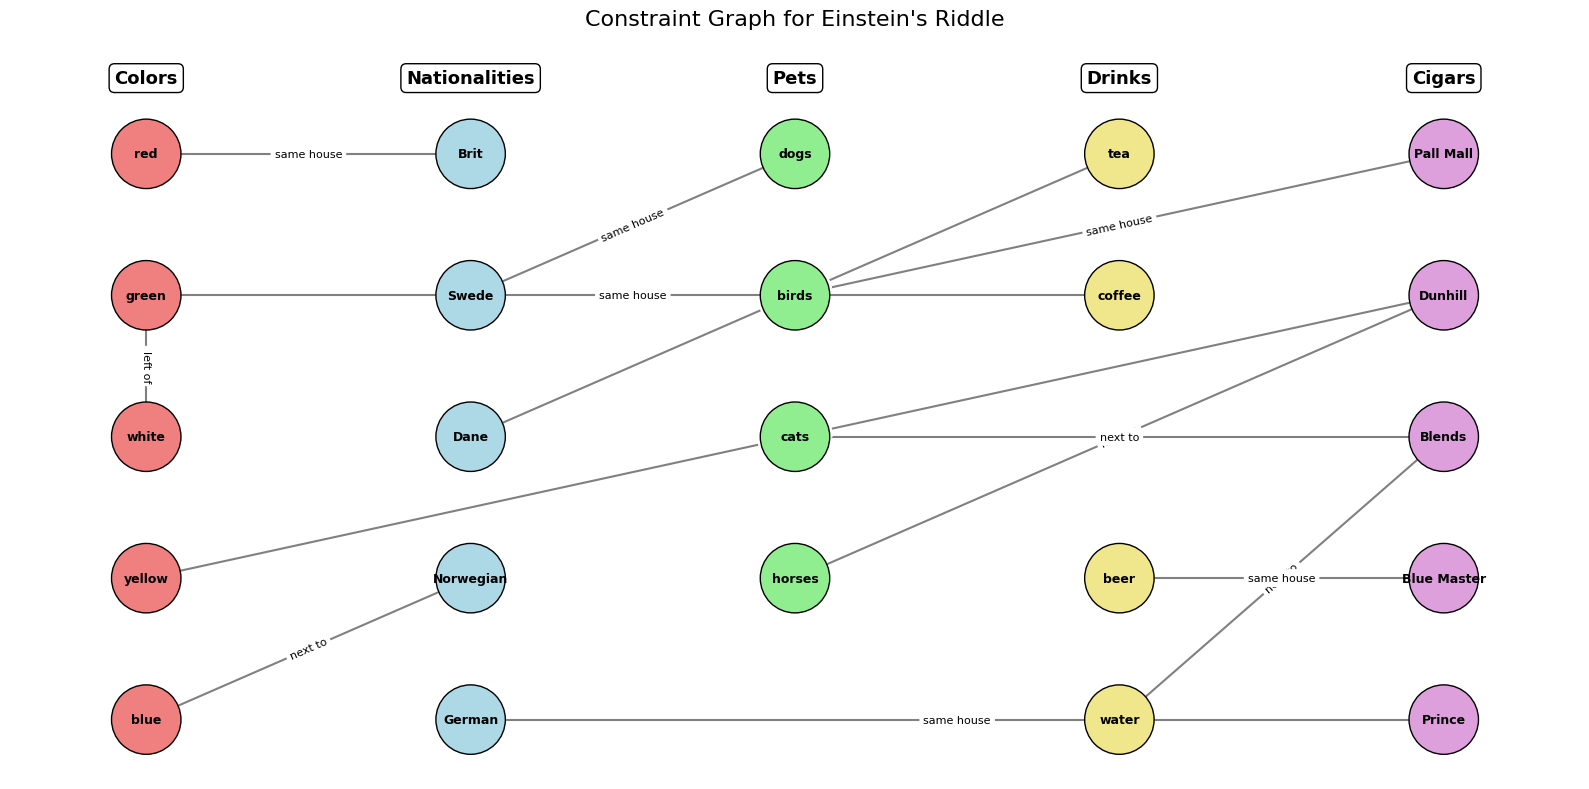

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# Categories
colors = ["red", "green", "white", "yellow", "blue"]
nationalities = ["Brit", "Swede", "Dane", "Norwegian", "German"]
pets = ["dogs", "birds", "cats", "horses", "fish"]
drinks = ["tea", "coffee", "milk", "beer", "water"]
cigars = ["Pall Mall", "Dunhill", "Blends", "Blue Master", "Prince"]

# Binary clue constraints
edges = [
    ("Brit", "red", "same house"),
    ("Swede", "dogs", "same house"),
    ("Dane", "tea", "same house"),
    ("green", "white", "left of"),
    ("green", "coffee", "same house"),
    ("Pall Mall", "birds", "same house"),
    ("yellow", "Dunhill", "same house"),
    ("Blends", "cats", "next to"),
    ("horses", "Dunhill", "next to"),
    ("Blue Master", "beer", "same house"),
    ("German", "Prince", "same house"),
    ("Norwegian", "blue", "next to"),
    ("Blends", "water", "next to"),
]

G = nx.Graph()

for u, v, label in edges:
    G.add_edge(u, v, label=label)

# Manual clustered layout
categories = {
    "Colors": colors,
    "Nationalities": nationalities,
    "Pets": pets,
    "Drinks": drinks,
    "Cigars": cigars,
}

x_positions = {
    "Colors": 0,
    "Nationalities": 3,
    "Pets": 6,
    "Drinks": 9,
    "Cigars": 12,
}

pos = {}

for category_name, nodes in categories.items():
    x = x_positions[category_name]
    for i, node in enumerate(nodes):
        # Negative i spaces nodes vertically
        pos[node] = (x, -i * 2)

# Node colors by category
node_color_map = {
    "Colors": "lightcoral",
    "Nationalities": "lightblue",
    "Pets": "lightgreen",
    "Drinks": "khaki",
    "Cigars": "plum",
}

node_colors = []

for node in G.nodes():
    for category_name, nodes in categories.items():
        if node in nodes:
            node_colors.append(node_color_map[category_name])
            break

plt.figure(figsize=(16, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=2500,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    width=1.5
)

edge_labels = nx.get_edge_attributes(G, "label")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.5
)

# Add category labels above each cluster
for category_name, x in x_positions.items():
    plt.text(
        x,
        1,
        category_name,
        fontsize=13,
        fontweight="bold",
        ha="center",
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3")
    )

plt.title("Constraint Graph for Einstein's Riddle", fontsize=16, pad=50)
plt.axis("off")
plt.tight_layout()
plt.show()

In addition to the clue edges, each category has an `AllDifferent` constraint. For example:
`AllDifferent(red, green, white, yellow, blue)`
means no two colors can occupy the same house. Similarly, we have:

```
AllDifferent(Brit, Swede, Dane, Norwegian, German)
AllDifferent(dogs, birds, cats, horses, fish)
AllDifferent(tea, coffee, milk, beer, water)
AllDifferent(Pall Mall, Dunhill, Blends, Blue Master, Prince)
```

The categories in the graph above implicitly have this constraint. This constraint is not drawn as edges to avoid clutter.

The clue classifications are as follows:

| No. | Clue                                                           | Type                         |
|----:|----------------------------------------------------------------|------------------------------|
|   1 | The Brit lives in the red house.                               | Binary equality              |
|   2 | The Swede keeps dogs.                                          | Binary equality              |
|   3 | The Dane drinks tea.                                           | Binary equality              |
|   4 | The green house is immediately to the left of the white house. | Positional binary constraint |
|   5 | The green house’s owner drinks coffee.                         | Binary equality              |
|   6 | Pall Mall smoker rears birds.                                  | Binary equality              |
|   7 | Yellow house owner smokes Dunhill.                             | Binary equality              |
|   8 | Center house drinks milk.                                      | Unary positional constraint  |
|   9 | Norwegian lives in the first house.                            | Unary positional constraint  |
|  10 | Blends smoker lives next to cats owner.                        | Positional binary constraint |
|  11 | Horses are next to Dunhill smoker.                             | Positional binary constraint |
|  12 | Blue Master smoker drinks beer.                                | Binary equality              |
|  13 | German smokes Prince.                                          | Binary equality              |
|  14 | Norwegian lives next to blue house.                            | Positional binary constraint |
|  15 | Blends smoker has neighbor who drinks water.                   | Positional binary constraint |

#### 2. Search Space Size
There are 5 categories - Color, Nationality, Pet, Drink, and Cigar. Each category contains 5 attributes that must be assigned to 5 houses. If we assume each category is a permutation of 5 distinct attributes across 5 houses, then each category has $5! = 120$ possible assignments. For 5 independent categories, there are $120^5 = 24,883,200,000$ possible assignments. A naive brute force solution would check all $24,883,200,000$ possibilities, which would take an insane amount of time.

However, if the solution is found optimally, after applying all the constraints, the puzzle has exactly $1$ valid solution, as demonstrated below:


In [16]:
from ortools.sat.python import cp_model

class SolutionCounter(cp_model.CpSolverSolutionCallback):
    def __init__(self):
        cp_model.CpSolverSolutionCallback.__init__(self)
        self.solution_count = 0

    def OnSolutionCallback(self):
        self.solution_count += 1

solver = cp_model.CpSolver()
counter = SolutionCounter()
solver.SearchForAllSolutions(model, counter)

print("Number of valid solutions:", counter.solution_count)

Number of valid solutions: 1


#### 3. Constraint Propagation
Before performing search, constraint propagation can reduce the possible domains of variables by eliminating values that cannot participate in any valid solution.

In Einstein’s Riddle, each item can be modeled as a variable whose domain is the set of house positions:

$$D(x) = \{1,2,3,4,5\}$$

For example:

$$red, green, Brit, tea, dogs, \ldots \in \{1,2,3,4,5\}$$

A constraint such as $Brit = red$ means that the Brit and the red house must have the same position. A positional constraint such as $green = white - 1$ means that the $green$ house must be immediately to the left of the $white$ house.

###### Unary Constraints
Unary constraints prune domains immediately. For example, $milk = 3$ because the center house drinks milk. Also, $Norwegian = 1$ because the Norwegian lives in the first house. So the domains become:

$$D(milk) = \{3\}$$
$$D(Norwegian) = \{1\}$$

These values can then be removed from the domains of other variables in the same `AllDifferent` group. For example, since $Norwegian$ is a nationality, no other nationality can be in house 1, so:

$$D(Brit), D(Swede), D(Dane), D(German) \neq 1$$

Similarly, since $milk$ is a drink, no other drink can be in house 3, so:

$$D(tea), D(coffee), D(beer), D(water) \neq 3$$

###### AC-3 Arc Consistency
AC-3 enforces consistency between pairs of variables. For each binary constraint, it checks whether every value in one variable’s domain has at least one compatible value in the other variable’s domain. If not, that value is removed. For example, the clue $green = white - 1$ requires the $green$ house to be immediately left of the $white$ house. Initially:

$$D(green) = D(white) = \{1,2,3,4,5\}$$

AC-3 removes impossible positions:

- $green$ cannot be 5, because there is no house 6 for $white$.
- $white$ cannot be 1, because there is no house 0 for $green$.

So:

$$D(green) = \{1,2,3,4\}$$

$$D(white) = \{2,3,4,5\}$$

The clue that $Norwegian$ is next to $blue$ combined with the constraint $Norwegian = 1$ forces $blue = 2$ because the only neighbor of house 1 is house 2. This then propagates through the `AllDifferent` constraint for colors, so no other color can be in house 2.

###### Forward Checking

Forward checking performs pruning whenever a variable is assigned. For example, once we assign $Norwegian = 1$, forward checking removes house 1 from the domains of the other nationalities. Then, using the constraint that $Norwegian$ is next to $blue$, it restricts $blue$ to house 2.

Similarly, once we assign $milk$ to house 3, forward checking removes house 3 from the other drink domains.

If later we assign $green$ to house 4, then forward checking immediately forces $white$ to house 5 because the $white$ house must be immediately to the right of the $green$ house.

###### Effect on the Search Space

Constraint propagation greatly reduces the number of possibilities before any brute-force search is attempted. Instead of blindly checking all $24,883,200,000$ possible assignments, the solver eliminates inconsistent values early. This pruning makes the remaining search space much smaller and allows backtracking or CP-SAT solving to find the solution efficiently.

#### 4. Complexity
Let $n$ be the number of variables and $d$ be the maximum domain size. Here, $n = 25$ and $d = 5$.

###### Pure backtracking
Pure backtracking tries assignments recursively and checks constraints after assignments. This problem has a permutation structure, because within each category, the five attributes must be assigned to the five houses exactly once. In the worst case, pure backtracking still searches every possible assignment, even if infeasible. So, the time complexity is $O(d!^n)$.

###### Backtracking with Constraint Propagation
Backtracking with constraint propagation still has a time complexity of $O(d!^n)$, because in the worst case, it can still search every possible assignment. However, the practical runtime is much better. Constraint propagation, such as forward checking or AC-3, prunes inconsistent values from variable domains before and during search. This reduces the effective branching factor from $d!$ to a smaller value $b$. So, the practical runtime behaves more like $O(b^n)$ where $b < d!$.

#### 5. Reflection
The puzzle has a unique solution because the constraints interact very tightly. Some clues fix absolute positions while others force adjacency. Also, some clues tie attributes together in the same house. Individually, each clue eliminates only part of the search space. But together, they interact to eliminate almost every possible assignment.

For example, the constraint that $Norwegian$ is in house 1 combined with the constraint that $Norwegian$ is next to $blue$ implies that $blue$ is in house 2. Then, the `AllDifferent` constraints restrict the other colors. The center house drinks $milk$, so the $green$ house cannot be the center because the $green$ house drinks $coffee$. Since $green$ must be immediately left of $white$, this greatly restricts the possible locations of $green$ and $white$.

This cascading effect is what makes CSP methods powerful. A CSP solver does not blindly enumerate all possible assignments. Instead, it reasons locally using constraints, prunes invalid partial assignments early, and quickly converges to the only globally consistent assignment. Einstein’s Riddle is a good example of how a seemingly enormous search problem can become easy when represented with the right variables, constraints, and propagation methods.

# Q2 — Inference in Bayesian Networks

## 30 points total

Consider the following Bayesian network representing a simplified medical diagnosis scenario:

- Flu ($F$): binary variable (Yes/No)
- Cold ($C$): binary variable (Yes/No)
- Fever ($Fe$): depends on Flu and Cold
- Cough ($Co$): depends on Cold
- Fatigue ($Fa$): depends on Flu

**Conditional Probability Tables (CPTs)**
- Prior probabilities:
    - $P$($F$ = Yes) = 0.05, $P$($F$ = No) = 0.95
    - $P$($C$ = Yes) = 0.10, $P$($C$ = No) = 0.90
- Conditional distributions:
    - $P$($Fe$ = Yes | $F$, $C$):
        - Flu = Yes, Cold = Yes → 0.90
        - Flu = Yes, Cold = No → 0.80
        - Flu = No, Cold = Yes → 0.70
        - Flu = No, Cold = No → 0.05
    - $P$($Co$ = Yes | Cold):
        - Cold = Yes → 0.80
        - Cold = No → 0.10
    - $P$($Fa$ = Yes | Flu):
        - Flu = Yes → 0.75
        - Flu = No → 0.20


### [10 points] Exact Inference

Compute the posterior probability that a patient has Flu, given that they present with Fever = Yes and Cough = Yes.

$$P(F = \text{Yes} | Fe = \text{Yes}, Co = \text{Yes})$$

Show the numerator, denominator/normalization step, and final posterior.

### [10 points] Approximate Inference
Outline how you would estimate the same posterior using Likelihood Weighting. Describe:
- How you would generate samples
- How evidence is handled
- How weights are assigned
- How the posterior is approximated from weighted samples

### [10 points] Scalability and Trade-offs
Explain why exact inference may become expensive in larger Bayesian networks. Compare exact inference and likelihood weighting in terms of accuracy, computational cost, scalability, and limitations.

### Your response goes here

# Q3 — Principal Component Analysis on MNIST  

## 35 points total

In this problem, you will implement **Principal Component Analysis (PCA)** from scratch using the MNIST dataset. You must not use the built-in PCA functions in scikit-learn. Instead, you will write the steps yourself using NumPy. Use at least **1000 samples** and ensure the data is class-balanced.  

You may download the dataset from either of the following sources:  
- Import directly into your notebook
- Alternative dataset links: [GTDLBench](https://git-disl.github.io/GTDLBench/datasets/mnist_datasets/), [Kaggle](https://www.kaggle.com/datasets/hojjatk/mnist-dataset), [Hugging Face](https://huggingface.co/datasets/ylecun/mnist)

---

### [15 points] Part A – Coding (Implementation)  

### Data Preparation  
- Load MNIST 
- Select at least **1000 balanced samples**.  
- Flatten images into vectors and **standardize the data**.  

### PCA from Scratch  
- Compute the **covariance matrix**.  
- Find **eigenvalues** and **eigenvectors**.  
- Sort eigenvalues and project the data into the new space.  

### Variance Explained  
- Plot the **explained variance** (scree plot).  
- Determine how many principal components to retain.  

---

### [20 points] Part B – Analysis (Explanation)  

### Component Selection  
- Justify your choice of how many components to keep.  
- Discuss trade-offs between dimensionality reduction and information retention.  

### Visualization  
- Create at least **five distinct 2D scatter plots** of the data projected onto different pairs of principal components (e.g., PC1 vs. PC2, PC2 vs. PC3, etc.), coloring points by digit class.  
- Comment on what these plots reveal about **class separability** and **structure** in the data.  

### Interpretation  
- Explain why each step of PCA matters (**covariance, eigenvalues, variance explained**).  
- Discuss one **real-world application** where PCA would be useful.  


In [ ]:
## Your code goes here

## Your analysis goes here